# Dressed-sum $U_{AB}$ Krylov protocols (steps 8–10)

This notebook mirrors the hetero-dimer interaction / size-consistency / singularity sections of the multibasis protocols notebook, but replaces the product Krylov

$$
|\Phi_{ij}\rangle = U_A^{i}\, U_B^{j}\, |\mathrm{HF}\rangle.
$$

with a **single-exponent** length-$N$ chain built from the **sum of dressed fragment Hamiltonians**:

$$
H_A = H_a + \frac{1}{2} H_{ab},\qquad
H_B = H_b + \frac{1}{2} H_{ab},
$$

$$
U_{AB} = e^{-i(H_A+H_B)\Delta t},\qquad
|\Phi_k\rangle = U_{AB}^{k}\, |\mathrm{HF}\rangle,\quad k=0,\ldots,N-1.
$$

With this dressing, $H_A+H_B = H_{\mathrm{tot}}$ (up to numerical residual), so $U_{AB}$ coincides with joint evolution under $H_{\mathrm{tot}}$. We still construct $H_A$, $H_B$ explicitly and verify that

$$
\Vert H_a + H_b + H_{ab} - H_{\mathrm{tot}}\Vert
\quad\text{and}\quad
\Vert H_A + H_B - H_{\mathrm{tot}}\Vert
$$

are tiny. We also report $\Vert H_{ab}\Vert$ and the chemical interaction $\Delta = E_{\mathrm{dimer}} - E_A - E_B$ at $R = 1.1$ Å (interacting) and $R = 1000$ Å (non-interacting: $\Delta \to 0$).

| Section | Content |
|---|---|
| Hab check | $\Vert H_{ab}\Vert$ and dress residuals at $R=1.1$ vs $1000$ |
| **8** | H$_2$+H$_2$ interaction vs $N$ (STO-3G + 6-31G) |
| **9** | H$_2$+H$_4$ linear hetero-dimer |
| **8b/9b** | Size consistency at $R=1000$ with QKD monomers (6-31G) |
| **10** | Convergence + $S$ / $\tilde H$ singularity (power $U_{AB}$ + Lanczos) |


In [1]:
import gc
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.linalg as la
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh, expm_multiply, norm as sparse_norm

from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_nature.second_q.circuit.library import HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import ParityMapper

warnings.filterwarnings('ignore')

BOND = 0.735
R_LIST = [1000.0, 100.0, 10.0, 1.1]
R_INT = 1.1
R_NONINT = 1000.0
SVD_THRESH = 1e-10
CHEM_ACC = 1.6e-3
SPARSE_DIM_THRESHOLD = 256

BASIS_CONFIG = {
    'sto-3g': {'label': 'STO-3G', 'N_MAX': 6},
    '6-31g':  {'label': '6-31G',  'N_MAX': 6},
}
BASIS_LIST = list(BASIS_CONFIG.keys())

ROOT = os.getcwd()
FIG_ROOT = os.path.join(ROOT, 'output', 'krylov_dressed_sum_uab')
os.makedirs(FIG_ROOT, exist_ok=True)


def fig_dir(basis):
    d = os.path.join(FIG_ROOT, basis.replace('-', ''))
    os.makedirs(d, exist_ok=True)
    return d


print('Bases:', BASIS_LIST)
print('Figures ->', FIG_ROOT)


Bases: ['sto-3g', '6-31g']
Figures -> /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab


## 1. Helpers (dense + sparse)


In [2]:
def _pauli_support(label):
    n = len(label)
    return {n - 1 - j for j, ch in enumerate(label) if ch != 'I'}


def spectral_norm_sparse(H_sp):
    return float(sparse_norm(H_sp, ord=2))


def compute_dt(H_matrix):
    return np.pi / float(np.linalg.norm(H_matrix, ord=2))


def compute_dt_sparse(H_sp):
    return np.pi / spectral_norm_sparse(H_sp)


def exact_gs_electronic(H_dense=None, H_sp=None):
    if H_sp is not None:
        val, _ = eigsh(H_sp, k=1, which='SA')
        return float(val[0].real)
    return float(np.linalg.eigvalsh(H_dense)[0].real)


def build_sparse_hamiltonian(H_op):
    return H_op.to_matrix(sparse=True).tocsr()


def build_h2_monomer(basis, bond=BOND):
    half = bond / 2.0
    mol = MoleculeInfo(
        symbols=['H', 'H'],
        coords=[(0.0, 0.0, -half), (0.0, 0.0, half)],
        charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    mapper = ParityMapper(num_particles=problem.num_particles)
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    H = H_op.to_matrix().astype(complex)
    gs_elec = float(np.linalg.eigvalsh(H)[0].real)
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    ref = np.array(Statevector(hf.decompose()).data, dtype=complex)
    return {
        'H': H, 'H_op': H_op, 'ref': ref,
        'E_nuc': problem.nuclear_repulsion_energy,
        'n_qubits': H_op.num_qubits,
        'gs_elec': gs_elec,
        'gs_total': gs_elec + problem.nuclear_repulsion_energy,
        'basis': basis,
    }


def build_h2_dimer(R_angstrom, basis, bond=BOND):
    b2 = bond / 2.0
    zA, zB = -R_angstrom / 2.0, R_angstrom / 2.0
    mol = MoleculeInfo(
        symbols=['H', 'H', 'H', 'H'],
        coords=[
            (0.0, 0.0, zA - b2), (0.0, 0.0, zA + b2),
            (0.0, 0.0, zB - b2), (0.0, 0.0, zB + b2),
        ],
        charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    mapper = ParityMapper(num_particles=problem.num_particles)
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    joint_dim = 2 ** H_op.num_qubits
    use_sparse = joint_dim > SPARSE_DIM_THRESHOLD
    H_sp = build_sparse_hamiltonian(H_op) if use_sparse else None
    H = None if use_sparse else H_op.to_matrix().astype(complex)
    gs_elec = exact_gs_electronic(H_dense=H, H_sp=H_sp)
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    ref = np.array(Statevector(hf.decompose()).data, dtype=complex)
    return {
        'H': H, 'H_op': H_op, 'H_sp': H_sp, 'ref': ref,
        'E_nuc': problem.nuclear_repulsion_energy,
        'n_qubits': H_op.num_qubits, 'joint_dim': joint_dim,
        'gs_elec': gs_elec,
        'gs_total': gs_elec + problem.nuclear_repulsion_energy,
        'R': R_angstrom, 'use_sparse': use_sparse, 'basis': basis,
    }

# Sanity check -> look into PYSCF driver and get molecular coefficients from molecular coefficient matrix
# Check for non-interacting case and see if you can get explicit support on mol A and mol B -> check if function below is correct
# Build interacting case and compare to see if you can determine partitions -> check if function below is correct
def partition_hamiltonian(H_op, qubits_a, qubits_b, use_sparse=False):
    qa, qb = set(qubits_a), set(qubits_b)
    pa, pb, pab, ca, cb, cab = [], [], [], [], [], []
    for pauli, coeff in zip(H_op.paulis, H_op.coeffs):
        label = pauli.to_label()
        sup = _pauli_support(label)
        c = complex(coeff)
        if sup <= qa:
            pa.append(label); ca.append(c)
        elif sup <= qb:
            pb.append(label); cb.append(c)
        else:
            pab.append(label); cab.append(c)

    def to_op(labels, coeffs):
        n = 2 ** H_op.num_qubits
        if not labels:
            return csr_matrix((n, n), dtype=complex) if use_sparse else np.zeros((n, n), dtype=complex)
        op = SparsePauliOp.from_list(list(zip(labels, coeffs)))
        return op.to_matrix(sparse=True).tocsr() if use_sparse else op.to_matrix().astype(complex)

    H_a, H_b, H_ab = to_op(pa, ca), to_op(pb, cb), to_op(pab, cab)
    if use_sparse:
        H_tot = H_op.to_matrix(sparse=True).tocsr()
        residual = spectral_norm_sparse(H_tot - (H_a + H_b + H_ab))
    else:
        H_tot = H_op.to_matrix().astype(complex)
        residual = float(np.linalg.norm(H_tot - H_a - H_b - H_ab, ord=2))
    return {'H_a': H_a, 'H_b': H_b, 'H_ab': H_ab, 'H_tot': H_tot, 'residual': residual}


def build_dressed(H_a, H_b, H_ab):
    return H_a + 0.5 * H_ab, H_b + 0.5 * H_ab


def build_krylov_states(H_matrix, psi_ref, krylov_dim, dt):
    U = la.expm(-1j * H_matrix * dt)
    states = [psi_ref.copy().astype(complex)]
    for _ in range(1, krylov_dim):
        states.append(U @ states[-1])
    return states


def build_krylov_states_sparse(H_sp, psi_ref, krylov_dim, dt):
    # Fast sparse chain: iterative expm_multiply (copy_4 / step3f).
    states = [psi_ref.copy().astype(complex)]
    for _ in range(1, krylov_dim):
        states.append(expm_multiply(-1j * dt * H_sp, states[-1]))
    return states


def build_krylov_matrices(H_matrix, states):
    Psi = np.column_stack(states)
    S = Psi.conj().T @ Psi
    Ht = Psi.conj().T @ (H_matrix @ Psi)
    return S, Ht


def build_krylov_projected_sparse(H_sp, states):
    # Project sparse H into Krylov subspace without densifying H (copy_4).
    Psi = np.column_stack(states)
    S = Psi.conj().T @ Psi
    Ht = Psi.conj().T @ (H_sp @ Psi)
    return S, Ht


def build_product_states_dense(H_A, H_B, ref, N, dt):
    U_A = la.expm(-1j * dt * H_A)
    U_B = la.expm(-1j * dt * H_B)
    b_chain = [ref.copy().astype(complex)]
    for _ in range(1, N):
        b_chain.append(U_B @ b_chain[-1])
    a_chain = [np.eye(H_A.shape[0], dtype=complex)]
    for _ in range(1, N):
        a_chain.append(U_A @ a_chain[-1])
    return [a_chain[i] @ b_chain[j] for i in range(N) for j in range(N)]


def build_product_states_sparse(H_A_sp, H_B_sp, ref, N, dt):
    # O(N^2) sparse product grid: |Phi_ij> = U_A^i U_B^j |ref>.
    # Layer-by-layer U_A application: N + N(N-1) = N^2 matvecs.
    ref = ref.astype(complex)
    b_chain = [ref.copy()]
    for _ in range(1, N):
        b_chain.append(expm_multiply(-1j * dt * H_B_sp, b_chain[-1]))
    curr = list(b_chain)
    states = []
    for i in range(N):
        states.extend(curr)
        if i < N - 1:
            curr = [expm_multiply(-1j * dt * H_A_sp, s) for s in curr]
    return states


def solve_gen_eig(H_tilde, S_tilde, threshold=SVD_THRESH):
    s_vals, s_vecs = la.eigh(S_tilde)
    s_vecs = s_vecs.T
    good = np.array([v for val, v in zip(s_vals, s_vecs) if val > threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    e_gs = float(la.eigh(H_reg, S_reg)[0][0].real)
    return e_gs, len(good)


def energy_from_states(H_or_sp, states, E_nuc, use_sparse=False, threshold=SVD_THRESH):
    if use_sparse:
        S, Ht = build_krylov_projected_sparse(H_or_sp, states)
    else:
        S, Ht = build_krylov_matrices(H_or_sp, states)
    gs_elec, eff_dim = solve_gen_eig(Ht, S, threshold)
    return {
        'gs_elec': gs_elec,
        'gs_total': gs_elec + E_nuc,
        'eff_dim': eff_dim,
        'raw_dim': len(states),
        'S': S,
        'H': Ht,
    }


def build_all_systems(basis, R_list):
    mono = build_h2_monomer(basis)
    qa = list(range(mono['n_qubits']))
    qb = list(range(mono['n_qubits'], 2 * mono['n_qubits']))
    systems = {}
    for R in R_list:
        dim = build_h2_dimer(R, basis)
        us = dim['use_sparse']
        part = partition_hamiltonian(dim['H_op'], qa, qb, use_sparse=us)
        H_A, H_B = build_dressed(part['H_a'], part['H_b'], part['H_ab'])
        if us:
            dress_res = spectral_norm_sparse(part['H_tot'] - H_A - H_B)
            norm_ab = spectral_norm_sparse(part['H_ab'])
            dt_tot = compute_dt_sparse(part['H_tot'])
        else:
            dress_res = float(np.linalg.norm(H_A + H_B - part['H_tot'], 2))
            norm_ab = float(np.linalg.norm(part['H_ab'], 2))
            dt_tot = compute_dt(part['H_tot'])
        sys = {
            **dim, **part,
            'H_A': H_A, 'H_B': H_B,
            'E_exact_sum': 2.0 * mono['gs_total'],
            'delta_exact': dim['gs_total'] - 2.0 * mono['gs_total'],
            'dress_residual': dress_res,
            'dt_tot': dt_tot,
            'dt_mono': compute_dt(mono['H']),
            'qubits_a': qa, 'qubits_b': qb,
            'norm_H_ab': norm_ab,
        }
        if us:
            sys['H_tot_sp'] = part['H_tot']
            sys['H_A_sp'] = H_A
            sys['H_B_sp'] = H_B
        systems[R] = sys
        gc.collect()
    return mono, systems


print('Helpers ready (dense + sparse fast paths).')


Helpers ready (dense + sparse fast paths).


## 2. Sweep utilities


In [3]:
def _H_tot_of(sys):
    return sys['H_tot_sp'] if sys['use_sparse'] else sys['H_tot']


def _H_A_of(sys):
    return sys['H_A_sp'] if sys['use_sparse'] else sys['H_A']


def _H_B_of(sys):
    return sys['H_B_sp'] if sys['use_sparse'] else sys['H_B']


def sweep_joint(sys, dims):
    # One-shot joint chain at max(dims); slice submatrices (copy_4 style).
    max_n = max(dims)
    H = _H_tot_of(sys)
    if sys['use_sparse']:
        states = build_krylov_states_sparse(H, sys['ref'], max_n, sys['dt_tot'])
        S_full, H_full = build_krylov_projected_sparse(H, states)
    else:
        states = build_krylov_states(H, sys['ref'], max_n, sys['dt_tot'])
        S_full, H_full = build_krylov_matrices(H, states)
    rows = []
    for N in dims:
        gs_elec, eff = solve_gen_eig(H_full[:N, :N], S_full[:N, :N])
        rows.append({
            'N': N, 'raw_dim': N, 'eff_dim': eff,
            'gs_total': gs_elec + sys['E_nuc'],
            'gs_err': abs(gs_elec + sys['E_nuc'] - sys['gs_total']),
        })
    return pd.DataFrame(rows)


def sweep_novel(sys, dims):
    # One-shot dressed product grid at max N; extract N x N blocks.
    max_n = max(dims)
    H = _H_tot_of(sys)
    HA, HB = _H_A_of(sys), _H_B_of(sys)
    if sys['use_sparse']:
        states_full = build_product_states_sparse(HA, HB, sys['ref'], max_n, sys['dt_tot'])
        S_full, H_full = build_krylov_projected_sparse(H, states_full)
    else:
        states_full = build_product_states_dense(HA, HB, sys['ref'], max_n, sys['dt_tot'])
        S_full, H_full = build_krylov_matrices(H, states_full)
    assert len(states_full) == max_n * max_n

    rows = []
    for N in dims:
        # Layer-major order: index = i*max_n + j
        idx = [i * max_n + j for i in range(N) for j in range(N)]
        S = S_full[np.ix_(idx, idx)]
        Ht = H_full[np.ix_(idx, idx)]
        gs_elec, eff = solve_gen_eig(Ht, S)
        gs_total = gs_elec + sys['E_nuc']
        rows.append({
            'N': N, 'raw_dim': N * N, 'eff_dim': eff,
            'gs_total': gs_total,
            'gs_err': abs(gs_total - sys['gs_total']),
        })
    return pd.DataFrame(rows)


def energy_at_N(sys, N, procedure):
    H = _H_tot_of(sys)
    if procedure == 'novel':
        HA, HB = _H_A_of(sys), _H_B_of(sys)
        if sys['use_sparse']:
            states = build_product_states_sparse(HA, HB, sys['ref'], N, sys['dt_tot'])
        else:
            states = build_product_states_dense(HA, HB, sys['ref'], N, sys['dt_tot'])
        assert len(states) == N * N
    else:
        if sys['use_sparse']:
            states = build_krylov_states_sparse(H, sys['ref'], N, sys['dt_tot'])
        else:
            states = build_krylov_states(H, sys['ref'], N, sys['dt_tot'])
    return energy_from_states(H, states, sys['E_nuc'], use_sparse=sys['use_sparse'])


print('Sweep helpers ready.')


Sweep helpers ready.


## 3. Enrichment / product / hybrid builders (controls)


In [4]:
# ---------------------------------------------------------------------------
# Protocol 3 enrichment helpers
# Reuse the same sparse/dense machinery as the main notebook.
# ---------------------------------------------------------------------------

def build_product_states_BA(H_A, H_B, ref, N, dt, use_sparse=False):
    """Opposite-order dressed grid: |Phi_ij> = U_B^j U_A^i |HF>.

    When [H_A, H_B] != 0, this is *not* the same as U_A^i U_B^j |HF>.
    Including both orderings can open new directions while staying dressed.
    """
    if use_sparse:
        # Build A-chain first: |a_i> = U_A^i |HF>
        ref = ref.astype(complex)
        a_chain = [ref.copy()]
        for _ in range(1, N):
            a_chain.append(expm_multiply(-1j * dt * H_A, a_chain[-1]))
        # Then apply U_B^j to each |a_i>
        states = []
        for i in range(N):
            for j in range(N):
                state = a_chain[i]
                for _ in range(j):
                    state = expm_multiply(-1j * dt * H_B, state)
                states.append(state)
        return states

    # Dense path: matrix powers
    U_A = la.expm(-1j * dt * H_A)
    U_B = la.expm(-1j * dt * H_B)
    a_chain = [ref.copy().astype(complex)]
    for _ in range(1, N):
        a_chain.append(U_A @ a_chain[-1])
    b_ops = [np.eye(H_B.shape[0], dtype=complex)]
    for _ in range(1, N):
        b_ops.append(U_B @ b_ops[-1])
    return [b_ops[j] @ a_chain[i] for i in range(N) for j in range(N)]


def build_both_order_states(sys, N):
    """Union of AB-order and BA-order dressed grids (raw size up to 2 N^2)."""
    HA, HB = _H_A_of(sys), _H_B_of(sys)
    us = sys['use_sparse']
    dt = sys['dt_tot']
    ref = sys['ref']
    if us:
        ab = build_product_states_sparse(HA, HB, ref, N, dt)
    else:
        ab = build_product_states_dense(HA, HB, ref, N, dt)
    ba = build_product_states_BA(HA, HB, ref, N, dt, use_sparse=us)
    return ab + ba


def build_multidt_states(sys, N, dt_scales=(0.5, 1.0, 1.5)):
    """Dressed AB grid at several timesteps; concatenate all of them.

    One Delta-t can make consecutive Krylov vectors look similar.
    A few different Delta-t values explore the spectrum more evenly.
    """
    HA, HB = _H_A_of(sys), _H_B_of(sys)
    us = sys['use_sparse']
    ref = sys['ref']
    dt0 = sys['dt_tot']
    states = []
    for scale in dt_scales:
        dt = dt0 * scale
        if us:
            states.extend(build_product_states_sparse(HA, HB, ref, N, dt))
        else:
            states.extend(build_product_states_dense(HA, HB, ref, N, dt))
    return states


def build_hybrid_states(sys, N, n_joint=None):
    """Dressed novel grid PLUS a short joint Krylov chain on H_tot.

    Dressed part: size-consistency-friendly product structure.
    Joint part: small patch that can reach entangled corrections the grid misses.
    """
    if n_joint is None:
        n_joint = N
    HA, HB = _H_A_of(sys), _H_B_of(sys)
    H = _H_tot_of(sys)
    us = sys['use_sparse']
    ref = sys['ref']
    dt = sys['dt_tot']
    if us:
        novel = build_product_states_sparse(HA, HB, ref, N, dt)
        joint = build_krylov_states_sparse(H, ref, n_joint, dt)
    else:
        novel = build_product_states_dense(HA, HB, ref, N, dt)
        joint = build_krylov_states(H, ref, n_joint, dt)
    return novel + joint


def energy_from_state_list(sys, states):
    """Ritz energy of H_tot in the span of `states` (+ nuclear repulsion)."""
    H = _H_tot_of(sys)
    return energy_from_states(H, states, sys['E_nuc'], use_sparse=sys['use_sparse'])


print('Enrichment helpers ready:')
print('  - both orderings (AB + BA)')
print('  - multi-Delta-t dressed grid')
print('  - hybrid (dressed + joint)')


Enrichment helpers ready:
  - both orderings (AB + BA)
  - multi-Delta-t dressed grid
  - hybrid (dressed + joint)


## 4. H₂+H₄ builders


In [5]:
# §9 helpers — H2 / H4 monomers + linear H2+H4 dimer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

H2H4_N_MAX = {'sto-3g': 6, '6-31g': 6}
H2H4_VARIANTS = ['novel', 'both_order', 'hybrid', 'joint']
H2H4_BASIS_LIST = list(BASIS_CONFIG.keys())
R_H2H4_INT = 1.1
R_H2H4_NON = 1000.0


def _linear_h2_coords(z0=0.0, bond=BOND):
    return [(0.0, 0.0, z0), (0.0, 0.0, z0 + bond)]


def _linear_h4_coords(z0, bond=BOND):
    return [(0.0, 0.0, z0 + i * bond) for i in range(4)]


def build_h_chain_monomer(n_atoms, basis='sto-3g', bond=BOND, cas=None):
    """Monomer Hamiltonian + exact GS (and HF ref for QKD).

    cas=None -> full space with ParityMapper.
    cas=(n_elec, n_spatial) -> ActiveSpaceTransformer + JordanWigner.
    For H2+H4 / 6-31G CAS(6e,6o) dimers use cas=(2,2) for H2 and cas=(4,4)
    for H4 so E(H2)+E(H4) matches E_CAS(R=1000).
    """
    coords = [(0.0, 0.0, i * bond) for i in range(n_atoms)]
    mol = MoleculeInfo(
        symbols=['H'] * n_atoms, coords=coords, charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    if cas is not None:
        n_elec, n_orb = cas
        problem = ActiveSpaceTransformer(
            num_electrons=n_elec, num_spatial_orbitals=n_orb,
        ).transform(problem)
        mapper = JordanWignerMapper()
        active_label = f'cas{n_elec}e{n_orb}o'
    else:
        mapper = ParityMapper(num_particles=problem.num_particles)
        active_label = 'full'

    H_op = mapper.map(problem.hamiltonian.second_q_op())
    joint_dim = 2 ** H_op.num_qubits
    use_sparse = joint_dim > SPARSE_DIM_THRESHOLD
    H_sp = build_sparse_hamiltonian(H_op) if use_sparse else None
    H = None if use_sparse else H_op.to_matrix().astype(complex)
    gs_elec = exact_gs_electronic(H_dense=H, H_sp=H_sp)
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    ref = np.array(Statevector(hf.decompose()).data, dtype=complex)
    return {
        'n_atoms': n_atoms,
        'H': H, 'H_sp': H_sp, 'H_op': H_op, 'ref': ref,
        'E_nuc': problem.nuclear_repulsion_energy,
        'gs_elec': gs_elec,
        'gs_total': gs_elec + problem.nuclear_repulsion_energy,
        'n_qubits': H_op.num_qubits,
        'joint_dim': joint_dim,
        'use_sparse': use_sparse,
        'active_label': active_label,
        'basis': basis,
        'cas': cas,
    }


def sweep_mono_qkd(mono, dims, dt=None):
    """Finite-N joint QKD on an isolated monomer (electronic + nuclear).

    If dt is provided (e.g. the dimer dt_tot), use it so monomer and
    supermolecule Krylov share the same time step in SC tests.
    """
    us = bool(mono.get('use_sparse', False))
    H = mono['H_sp'] if us else mono['H']
    if dt is None:
        dt = compute_dt_sparse(H) if us else compute_dt(H)
    max_n = max(dims)
    if us:
        states = build_krylov_states_sparse(H, mono['ref'], max_n, dt)
        S_full, H_full = build_krylov_projected_sparse(H, states)
    else:
        states = build_krylov_states(H, mono['ref'], max_n, dt)
        S_full, H_full = build_krylov_matrices(H, states)
    rows = []
    for N in dims:
        gs_elec, eff = solve_gen_eig(H_full[:N, :N], S_full[:N, :N])
        E = gs_elec + mono['E_nuc']
        rows.append({
            'N': N,
            'E_mono_qkd': E,
            'eff_dim': eff,
            'gs_err': abs(E - mono['gs_total']),
        })
    return pd.DataFrame(rows)


def build_h2_h4_dimer(R_gap, basis='sto-3g', bond=BOND, use_cas66=False):
    # Linear H2+H4; JW mapping. For 6-31g set use_cas66 to reduce to 6 spatial orbs.
    coords_a = _linear_h2_coords(0.0, bond)
    coords_b = _linear_h4_coords(bond + R_gap, bond)
    coords = coords_a + coords_b
    mol = MoleculeInfo(
        symbols=['H'] * 6, coords=coords, charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    active_label = 'full'
    if use_cas66:
        problem = ActiveSpaceTransformer(
            num_electrons=6, num_spatial_orbitals=6,
        ).transform(problem)
        active_label = 'cas66'

    mapper = JordanWignerMapper()
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    joint_dim = 2 ** H_op.num_qubits
    use_sparse = joint_dim > SPARSE_DIM_THRESHOLD
    H_sp = build_sparse_hamiltonian(H_op) if use_sparse else None
    H = None if use_sparse else H_op.to_matrix().astype(complex)
    gs_elec = exact_gs_electronic(H_dense=H, H_sp=H_sp)
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    ref = np.array(Statevector(hf.decompose()).data, dtype=complex)

    # JW: 2 qubits / spatial orb. Assign first 2 spatial orbs to A, last 4 to B.
    n_spatial = problem.num_spatial_orbitals
    assert n_spatial == 6, f'expected 6 spatial orbs after basis/CAS, got {n_spatial}'
    n_q_a, n_q_b = 2 * 2, 2 * 4
    assert H_op.num_qubits == n_q_a + n_q_b
    qa = list(range(n_q_a))
    qb = list(range(n_q_a, n_q_a + n_q_b))
    return {
        'H': H, 'H_op': H_op, 'H_sp': H_sp, 'ref': ref,
        'E_nuc': problem.nuclear_repulsion_energy,
        'n_qubits': H_op.num_qubits, 'joint_dim': joint_dim,
        'gs_elec': gs_elec,
        'gs_total': gs_elec + problem.nuclear_repulsion_energy,
        'R_gap': R_gap, 'use_sparse': use_sparse, 'basis': basis,
        'active_label': active_label,
        'qubits_a': qa, 'qubits_b': qb,
        'coords': coords,
    }


def build_h2_h4_system(R_gap, mono_a, mono_b, basis='sto-3g', use_cas66=False):
    dim = build_h2_h4_dimer(R_gap, basis=basis, use_cas66=use_cas66)
    us = dim['use_sparse']
    part = partition_hamiltonian(
        dim['H_op'], dim['qubits_a'], dim['qubits_b'], use_sparse=us)
    H_A, H_B = build_dressed(part['H_a'], part['H_b'], part['H_ab'])
    if us:
        dress_res = spectral_norm_sparse(part['H_tot'] - H_A - H_B)
        norm_ab = spectral_norm_sparse(part['H_ab'])
        dt_tot = compute_dt_sparse(part['H_tot'])
    else:
        dress_res = float(np.linalg.norm(H_A + H_B - part['H_tot'], 2))
        norm_ab = float(np.linalg.norm(part['H_ab'], 2))
        dt_tot = compute_dt(part['H_tot'])
    E_mono_sum = mono_a['gs_total'] + mono_b['gs_total']
    sys = {
        **dim, **part,
        'H_A': H_A, 'H_B': H_B,
        'E_exact_sum': E_mono_sum,
        'delta_exact': dim['gs_total'] - E_mono_sum,
        'dress_residual': dress_res,
        'dt_tot': dt_tot,
        'norm_H_ab': norm_ab,
    }
    if us:
        sys['H_tot_sp'] = part['H_tot']
        sys['H_A_sp'] = H_A
        sys['H_B_sp'] = H_B
    return sys


print('H2+H4 builders ready (JW; 6-31G uses CAS 6e/6o).')


H2+H4 builders ready (JW; 6-31G uses CAS 6e/6o).


## 5. Core procedure: dressed-sum $U_{AB}$ Krylov

Primary method **`uab`**: Krylov chain under $H_{\mathrm{sum}} = H_A + H_B$,

$$
\Delta t = \frac{\pi}{\Vert H_{\mathrm{sum}}\Vert},\qquad
|\Phi_k\rangle = U_{AB}^{k}\, |\mathrm{HF}\rangle,\quad k=0,\ldots,N-1.
$$

Controls:
- **joint** — same chain but built from stored $H_{\mathrm{tot}}$ (should match `uab` when the dress residual is tiny)
- **novel** — product grid $U_A^{i}\,U_B^{j}|\mathrm{HF}\rangle$ ($N^2$ vectors)


In [6]:
# Core U_AB builders + shared variant map
N_MAX_DEFAULT = {'sto-3g': 6, '6-31g': 6}
CHEM_ACC = 1.6e-3


def _H_sum_of(sys):
    """H_A + H_B (dressed sum). Prefer sparse path when available."""
    if sys['use_sparse']:
        return _H_A_of(sys) + _H_B_of(sys)
    return _H_A_of(sys) + _H_B_of(sys)


def compute_dt_for(H, use_sparse):
    return compute_dt_sparse(H) if use_sparse else compute_dt(H)


def build_uab_states(sys, N):
    """Length-N Krylov: |Phi_k> = U_AB^k |HF>, U_AB = exp(-i (H_A+H_B) dt)."""
    Hsum = _H_sum_of(sys)
    us = sys['use_sparse']
    dt = compute_dt_for(Hsum, us)
    ref = sys['ref']
    if us:
        return build_krylov_states_sparse(Hsum, ref, N, dt)
    return build_krylov_states(Hsum, ref, N, dt)


def energy_uab(sys, N):
    """Ritz energy of H_tot in the U_AB Krylov subspace."""
    states = build_uab_states(sys, N)
    # Project H_tot (same as H_sum when dressed) for energy
    return energy_from_state_list(sys, states)


VARIANT_BUILDERS = {
    'uab': build_uab_states,
    'novel': lambda sys, N: (
        build_product_states_sparse(_H_A_of(sys), _H_B_of(sys), sys['ref'], N, sys['dt_tot'])
        if sys['use_sparse'] else
        build_product_states_dense(_H_A_of(sys), _H_B_of(sys), sys['ref'], N, sys['dt_tot'])
    ),
    'joint': lambda sys, N: (
        build_krylov_states_sparse(_H_tot_of(sys), sys['ref'], N, sys['dt_tot'])
        if sys['use_sparse'] else
        build_krylov_states(_H_tot_of(sys), sys['ref'], N, sys['dt_tot'])
    ),
    'hybrid': build_hybrid_states,
}

VARIANT_STYLE = {
    'uab':   {'color': '#9467bd', 'marker': 'P', 'ls': '-', 'lw': 2.4, 'ms': 9},
    'novel': {'color': '#1f77b4', 'marker': 'o', 'ls': '-', 'lw': 2.0, 'ms': 7},
    'joint': {'color': '#d62728', 'marker': '^', 'ls': '--', 'lw': 2.0, 'ms': 8},
    'hybrid':{'color': '#2ca02c', 'marker': 'D', 'ls': '-', 'lw': 2.0, 'ms': 7},
}

print('U_AB builders ready: uab / joint / novel / hybrid')


U_AB builders ready: uab / joint / novel / hybrid


## 6. Interaction-term check: $\Vert H_{ab}\Vert$ at $R=1.1$ vs $R=1000$

For dressed fragments, we report the spectral norm $\Vert H_{ab}\Vert$, the dress residual $\Vert H_a+H_b+H_{ab}-H_{\mathrm{tot}}\Vert$, and $\Vert H_A+H_B-H_{\mathrm{tot}}\Vert$, together with the chemical interaction

$$
\Delta = E_{\mathrm{dimer}}(R) - E_A - E_B.
$$

At large separation $\Delta \to 0$; the operator norm $\Vert H_{ab}\Vert$ need not vanish (nuclear / one-body cross terms can remain large in the JW representation).


Building systems for Hab / interaction checks ...
  H2+H2 STO-3G R=1.1: ||Hab||=5.023e+00  dress=2.22e-15  ||HA+HB-Htot||=2.22e-15  Delta=6.471e-01
  H2+H2 STO-3G R=1000: ||Hab||=2.342e+00  dress=2.22e-15  ||HA+HB-Htot||=2.22e-15  Delta=1.421e-14
  H2+H4 STO-3G R=1.1: ||Hab||=3.271e+00  dress=6.22e-15  ||HA+HB-Htot||=7.11e-15  Delta=3.904e-02
  H2+H4 STO-3G R=1000: ||Hab||=2.408e+00  dress=7.55e-15  ||HA+HB-Htot||=7.99e-15  Delta=5.984e-12
  H2+H2 6-31G R=1.1: ||Hab||=1.497e+01  dress=3.02e-14  ||HA+HB-Htot||=2.84e-14  Delta=5.247e-01
  H2+H2 6-31G R=1000: ||Hab||=9.068e+00  dress=1.60e-14  ||HA+HB-Htot||=1.60e-14  Delta=-2.331e-09
  H2+H4 6-31G R=1.1: ||Hab||=2.593e+00  dress=7.88e-15  ||HA+HB-Htot||=7.99e-15  Delta=2.886e-02
  H2+H4 6-31G R=1000: ||Hab||=1.789e+00  dress=6.05e-15  ||HA+HB-Htot||=6.22e-15  Delta=4.491e-09
Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/hab_norm_vs_R.csv

=== Interaction checks ===
H2+H2  sto-3g:
  ||Hab||  1.1

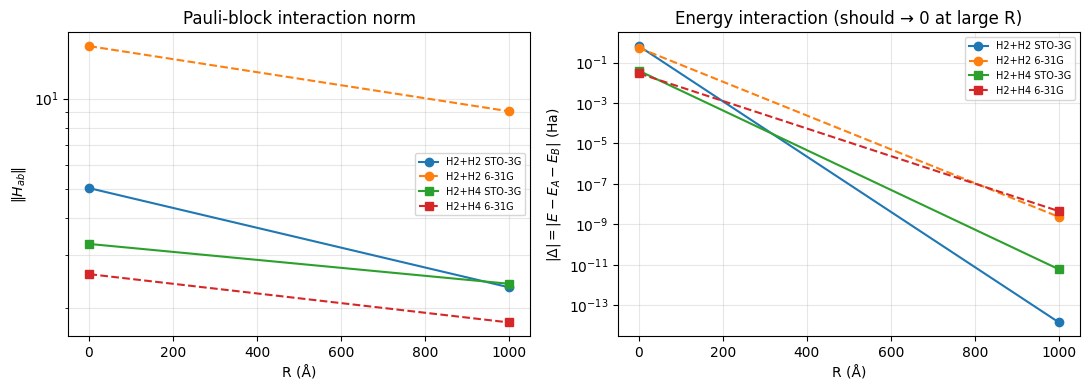

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/hab_norm_vs_R.png


In [7]:
# Hab / dress residual diagnostics
# Note: qubit-support partitioning can leave a large operator-norm ||Hab|| even at
# large R; the chemical interaction is the energy residual Delta = E - E_A - E_B.
hab_rows = []

print('Building systems for Hab / interaction checks ...')
for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    # H2+H2
    mono, systems = build_all_systems(basis, [R_INT, R_NONINT])
    for R in [R_INT, R_NONINT]:
        sys = systems[R]
        Hsum = _H_sum_of(sys)
        Htot = _H_tot_of(sys)
        if sys['use_sparse']:
            sum_res = spectral_norm_sparse(Hsum - Htot)
        else:
            sum_res = float(np.linalg.norm(Hsum - Htot, 2))
        hab_rows.append({
            'system': 'H2+H2', 'basis': basis, 'R': R,
            'joint_dim': sys['joint_dim'], 'use_sparse': sys['use_sparse'],
            'norm_H_ab': sys['norm_H_ab'],
            'dress_residual': sys['dress_residual'],
            'sum_minus_tot': sum_res,
            'delta_exact': sys['delta_exact'],
            'E': sys['gs_total'],
        })
        print(f'  H2+H2 {label} R={R:g}: ||Hab||={sys["norm_H_ab"]:.3e}  '
              f'dress={sys["dress_residual"]:.2e}  ||HA+HB-Htot||={sum_res:.2e}  '
              f'Delta={sys["delta_exact"]:.3e}')
    del systems, mono
    gc.collect()

    # H2+H4
    use_cas = (basis == '6-31g')
    if use_cas:
        mono_a = build_h_chain_monomer(2, basis=basis, cas=(2, 2))
        mono_b = build_h_chain_monomer(4, basis=basis, cas=(4, 4))
    else:
        mono_a = build_h_chain_monomer(2, basis=basis)
        mono_b = build_h_chain_monomer(4, basis=basis)
    for R in [R_H2H4_INT, R_H2H4_NON]:
        sys = build_h2_h4_system(R, mono_a, mono_b, basis=basis, use_cas66=use_cas)
        Hsum = _H_sum_of(sys)
        Htot = _H_tot_of(sys)
        if sys['use_sparse']:
            sum_res = spectral_norm_sparse(Hsum - Htot)
        else:
            sum_res = float(np.linalg.norm(Hsum - Htot, 2))
        d_ex = sys['delta_exact']  # vs CAS monomers when use_cas66
        hab_rows.append({
            'system': 'H2+H4', 'basis': basis, 'R': R,
            'joint_dim': sys['joint_dim'], 'use_sparse': sys['use_sparse'],
            'norm_H_ab': sys['norm_H_ab'],
            'dress_residual': sys['dress_residual'],
            'sum_minus_tot': sum_res,
            'delta_exact': d_ex,
            'E': sys['gs_total'],
            'active': sys['active_label'],
        })
        print(f'  H2+H4 {label} R={R:g}: ||Hab||={sys["norm_H_ab"]:.3e}  '
              f'dress={sys["dress_residual"]:.2e}  ||HA+HB-Htot||={sum_res:.2e}  '
              f'Delta={d_ex:.3e}')
        del sys
        gc.collect()
    del mono_a, mono_b
    gc.collect()

df_hab = pd.DataFrame(hab_rows)
df_hab.to_csv(os.path.join(FIG_ROOT, 'hab_norm_vs_R.csv'), index=False)
print('Saved:', os.path.join(FIG_ROOT, 'hab_norm_vs_R.csv'))

print()
print('=== Interaction checks ===')
for system in ['H2+H2', 'H2+H4']:
    R_i = R_INT if system == 'H2+H2' else R_H2H4_INT
    R_n = R_NONINT if system == 'H2+H2' else R_H2H4_NON
    for basis in BASIS_LIST:
        sub = df_hab[(df_hab['system'] == system) & (df_hab['basis'] == basis)]
        row_i = sub.loc[np.isclose(sub['R'], R_i)].iloc[0]
        row_n = sub.loc[np.isclose(sub['R'], R_n)].iloc[0]
        print(f'{system:6s} {basis:6s}:')
        print(f'  ||Hab||  1.1={row_i["norm_H_ab"]:.4e}  1000={row_n["norm_H_ab"]:.4e}')
        print(f'  Delta    1.1={row_i["delta_exact"]:.4e}  1000={row_n["delta_exact"]:.4e}')
        print(f'  dress_res / ||HA+HB-Htot|| at 1.1: '
              f'{row_i["dress_residual"]:.2e} / {row_i["sum_minus_tot"]:.2e}')
        # Chemical interaction energy near zero at large R (H2+H2 always; H2+H4 STO-3G)
        if system == 'H2+H2' or basis == 'sto-3g':
            assert abs(row_n['delta_exact']) < 1e-6, (
                f'{system}/{basis}: Delta at R=1000 should be ~0, got {row_n["delta_exact"]}')
        assert abs(row_i['delta_exact']) > 1e-3, (
            f'{system}/{basis}: Delta at R=1.1 should be non-zero')
        assert row_i['dress_residual'] < 1e-8
        assert row_i['sum_minus_tot'] < 1e-8
        assert row_i['norm_H_ab'] > 0.1

# Plots: ||Hab|| and |Delta|
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, ylab in [
    (axes[0], 'norm_H_ab', r'$\|H_{ab}\|$'),
    (axes[1], 'delta_exact', r'$|\Delta|=|E-E_A-E_B|$ (Ha)'),
]:
    for system, marker in [('H2+H2', 'o'), ('H2+H4', 's')]:
        for basis, ls in zip(BASIS_LIST, ['-', '--']):
            sub = df_hab[(df_hab['system'] == system) & (df_hab['basis'] == basis)].sort_values('R')
            y = np.abs(sub[key].to_numpy(dtype=float)) if key == 'delta_exact' else sub[key]
            ax.semilogy(sub['R'], np.maximum(y, 1e-16), marker+ls,
                        label=f'{system} {BASIS_CONFIG[basis]["label"]}')
    ax.set_xlabel('R (Å)'); ax.set_ylabel(ylab)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3, which='both')
axes[0].set_title('Pauli-block interaction norm')
axes[1].set_title('Energy interaction (should → 0 at large R)')
fig.tight_layout()
path = os.path.join(FIG_ROOT, 'hab_norm_vs_R.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


## 8. H$_2$+H$_2$ interaction energies — dressed-sum $U_{AB}$

$$
\Delta(N) = E_{\mathrm{method}}(R=1.1) - 2 E_{\mathrm{exact}}(\mathrm{H_2}),
\qquad
\mathrm{err}(N) = |\Delta(N) - \Delta_{\mathrm{exact}}|.
$$

Primary: **uab**. Controls: **joint**, **novel**.


In [8]:
# §8 — H2+H2 interaction sweep
HETERO_DIR = os.path.join(FIG_ROOT, 'hetero')
os.makedirs(HETERO_DIR, exist_ok=True)

H2H2_N_MAX = dict(N_MAX_DEFAULT)
H2H2_VARIANTS = ['uab', 'joint', 'novel']
h2h2_rows = []
delta_exact_h2h2 = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = H2H2_N_MAX[basis]
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'§8  H2+H2 U_AB interaction vs N  ({label})')
    print('=' * 60)

    mono, systems = build_all_systems(basis, [R_INT])
    sys = systems[R_INT]
    E_mono_sum = 2.0 * mono['gs_total']
    d_ex = sys['delta_exact']
    delta_exact_h2h2[basis] = d_ex
    print(f'  dim={sys["joint_dim"]}  ||Hab||={sys["norm_H_ab"]:.3e}  '
          f'Delta_exact={d_ex:.6f}')

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name in H2H2_VARIANTS:
            states = VARIANT_BUILDERS[name](sys, N)
            out = energy_from_state_list(sys, states)
            delta = out['gs_total'] - E_mono_sum
            h2h2_rows.append({
                'system': 'H2+H2', 'basis': basis, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'],
                'gs_err': abs(out['gs_total'] - sys['gs_total']),
                'delta': delta, 'delta_exact': d_ex,
                'err_int': abs(delta - d_ex),
            })
            print(f'{name}(err={abs(delta-d_ex):.2e})', end='  ')
        print()
        gc.collect()
    del systems, mono, sys
    gc.collect()
    print()

df_h2h2 = pd.DataFrame(h2h2_rows)
df_h2h2.to_csv(os.path.join(HETERO_DIR, 'h2h2_uab_interaction_vs_N.csv'), index=False)
print('Saved:', os.path.join(HETERO_DIR, 'h2h2_uab_interaction_vs_N.csv'))
for basis in BASIS_LIST:
    N_max = H2H2_N_MAX[basis]
    sub = df_h2h2[(df_h2h2['basis'] == basis) & (df_h2h2['N'] == N_max)]
    print(f"--- {BASIS_CONFIG[basis]['label']} at N={N_max} ---")
    print(sub[['variant', 'raw_dim', 'eff_dim', 'delta', 'err_int']].to_string(
        index=False, float_format=lambda x: f'{x:.4e}'))


§8  H2+H2 U_AB interaction vs N  (STO-3G)
  dim=64  ||Hab||=5.023e+00  Delta_exact=0.647096
  N=1 ... uab(err=4.66e-02)  joint(err=4.66e-02)  novel(err=4.66e-02)  
  N=2 ... uab(err=1.88e-02)  joint(err=1.88e-02)  novel(err=6.07e-03)  
  N=3 ... uab(err=6.59e-03)  joint(err=6.59e-03)  novel(err=8.74e-04)  
  N=4 ... uab(err=1.43e-03)  joint(err=1.43e-03)  novel(err=1.87e-04)  
  N=5 ... uab(err=5.47e-04)  joint(err=5.47e-04)  novel(err=9.21e-06)  
  N=6 ... uab(err=1.39e-04)  joint(err=1.39e-04)  novel(err=8.83e-07)  

§8  H2+H2 U_AB interaction vs N  (6-31G)
  dim=16384  ||Hab||=1.497e+01  Delta_exact=0.524750
  N=1 ... uab(err=5.99e-02)  joint(err=5.99e-02)  novel(err=5.99e-02)  
  N=2 ... uab(err=1.88e-02)  joint(err=1.88e-02)  novel(err=1.82e-02)  
  N=3 ... uab(err=7.84e-03)  joint(err=7.84e-03)  novel(err=7.19e-03)  
  N=4 ... uab(err=3.78e-03)  joint(err=3.78e-03)  novel(err=5.94e-03)  
  N=5 ... uab(err=1.80e-03)  joint(err=1.80e-03)  novel(err=5.83e-03)  
  N=6 ... uab(err=1.8

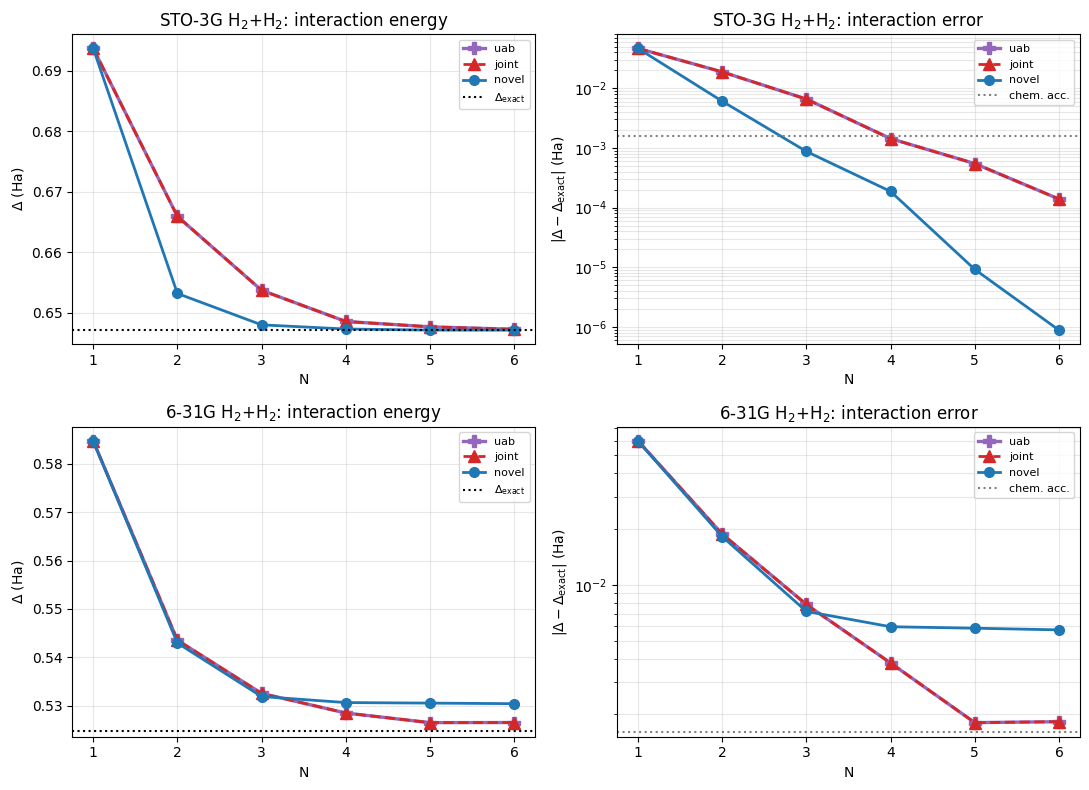

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/hetero/h2h2_uab_interaction_vs_N.png


In [9]:
# §8 plots
fig, axes = plt.subplots(len(BASIS_LIST), 2, figsize=(11, 4.0 * len(BASIS_LIST)))
if len(BASIS_LIST) == 1:
    axes = np.array([axes])
for row, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    sub = df_h2h2[df_h2h2['basis'] == basis]
    ax = axes[row, 0]
    for name in H2H2_VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['delta'], color=st['color'], marker=st['marker'],
                ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(delta_exact_h2h2[basis], color='k', ls=':', label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} H$_2$+H$_2$: interaction energy')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for name in H2H2_VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.semilogy(s['N'], np.maximum(s['err_int'], 1e-16),
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='chem. acc.')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ (Ha)')
    ax.set_title(rf'{label} H$_2$+H$_2$: interaction error')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
path = os.path.join(HETERO_DIR, 'h2h2_uab_interaction_vs_N.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


## 9. H$_2$+H$_4$ linear hetero-dimer — dressed-sum $U_{AB}$

Same geometry and CAS rules as the multibasis notebook.

$$
\Delta(N) = E_{\mathrm{method}}(R=1.1) - E_{\mathrm{ref}},
\qquad
\mathrm{err}(N) = |\Delta(N) - \Delta_{\mathrm{exact}}|.
$$

Reference $E_{\mathrm{ref}}$: exact monomers (STO-3G) or $E_{\mathrm{CAS}}(1000)$ (6-31G).


In [10]:
# §9 — H2+H4 interaction sweep
H2H4_N_MAX_LOCAL = dict(N_MAX_DEFAULT)
H2H4_VARIANTS = ['uab', 'joint', 'novel']
h2h4_rows = []
h2h4_p12_rows = []
delta_exact_h2h4 = {}
h2h4_sys_non = {}
h2h4_E_ref = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    use_cas66 = (basis == '6-31g')
    active_tag = 'cas66' if use_cas66 else 'full'
    N_max = H2H4_N_MAX_LOCAL[basis]
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'§9  H2+H4 U_AB  ({label}, {active_tag})')
    print('=' * 60)

    if use_cas66:
        mono_h2 = build_h_chain_monomer(2, basis=basis, cas=(2, 2))
        mono_h4 = build_h_chain_monomer(4, basis=basis, cas=(4, 4))
    else:
        mono_h2 = build_h_chain_monomer(2, basis=basis)
        mono_h4 = build_h_chain_monomer(4, basis=basis)
    print(f'  E(H2)={mono_h2["gs_total"]:.10f}  E(H4)={mono_h4["gs_total"]:.10f}')

    sys_non = build_h2_h4_system(
        R_H2H4_NON, mono_h2, mono_h4, basis=basis, use_cas66=use_cas66)
    sys_int = build_h2_h4_system(
        R_H2H4_INT, mono_h2, mono_h4, basis=basis, use_cas66=use_cas66)

    if use_cas66:
        E_ref = sys_non['gs_total']
        d_ex = sys_int['gs_total'] - E_ref
        sub_mode = 'cas_R1000'
        d_ex_p1 = d_ex
    else:
        E_ref = sys_int['E_exact_sum']
        d_ex = sys_int['delta_exact']
        sub_mode = 'monomers'
        d_ex_p1 = sys_int['gs_total'] - sys_non['gs_total']

    delta_exact_h2h4[basis] = d_ex
    h2h4_sys_non[basis] = sys_non
    h2h4_E_ref[basis] = E_ref

    print(f'  ||Hab||(1.1)={sys_int["norm_H_ab"]:.3e}  ||Hab||(1000)={sys_non["norm_H_ab"]:.3e}')
    print(f'  dim={sys_int["joint_dim"]}  Delta_exact={d_ex:.6f}  subtraction={sub_mode}')

    df_j_int = sweep_joint(sys_int, dims)
    df_j_non = sweep_joint(sys_non, dims)

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name in H2H4_VARIANTS:
            states = VARIANT_BUILDERS[name](sys_int, N)
            out = energy_from_state_list(sys_int, states)
            delta = out['gs_total'] - E_ref
            h2h4_rows.append({
                'system': 'H2+H4', 'basis': basis, 'label': label,
                'active': active_tag, 'subtraction': sub_mode,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'],
                'gs_err': abs(out['gs_total'] - sys_int['gs_total']),
                'delta': delta, 'delta_exact': d_ex,
                'err_int': abs(delta - d_ex),
            })
            print(f'{name}(err={abs(delta-d_ex):.2e})', end='  ')

        E_j_int = float(df_j_int.loc[df_j_int['N'] == N, 'gs_total'].iloc[0])
        E_j_non = float(df_j_non.loc[df_j_non['N'] == N, 'gs_total'].iloc[0])
        h2h4_p12_rows.append({
            'system': 'H2+H4', 'basis': basis, 'N': N,
            'delta_P1': E_j_int - E_j_non,
            'delta_P2': E_j_int - E_ref,
            'err_P1': abs((E_j_int - E_j_non) - d_ex_p1),
            'err_P2': abs((E_j_int - E_ref) - d_ex),
        })
        print()
        gc.collect()

    del sys_int, mono_h2, mono_h4
    gc.collect()
    print()

df_h2h4 = pd.DataFrame(h2h4_rows)
df_h2h4_p12 = pd.DataFrame(h2h4_p12_rows)
df_h2h4.to_csv(os.path.join(HETERO_DIR, 'h2h4_uab_interaction_vs_N.csv'), index=False)
df_h2h4_p12.to_csv(os.path.join(HETERO_DIR, 'h2h4_uab_protocol_p1_p2.csv'), index=False)
print('Saved h2h4 CSVs')
for basis in BASIS_LIST:
    N_max = H2H4_N_MAX_LOCAL[basis]
    sub = df_h2h4[(df_h2h4['basis'] == basis) & (df_h2h4['N'] == N_max)]
    print(f"--- {BASIS_CONFIG[basis]['label']} at N={N_max} ---")
    print(sub[['variant', 'raw_dim', 'eff_dim', 'delta', 'err_int']].to_string(
        index=False, float_format=lambda x: f'{x:.4e}'))


§9  H2+H4 U_AB  (STO-3G, full)
  E(H2)=-1.1373060358  E(H4)=-2.1355345984
  ||Hab||(1.1)=3.271e+00  ||Hab||(1000)=2.408e+00
  dim=4096  Delta_exact=0.039039  subtraction=monomers
  N=1 ... uab(err=6.05e-02)  joint(err=6.05e-02)  novel(err=6.05e-02)  
  N=2 ... uab(err=9.25e-03)  joint(err=9.25e-03)  novel(err=8.06e-03)  
  N=3 ... uab(err=2.23e-03)  joint(err=2.23e-03)  novel(err=2.23e-03)  
  N=4 ... uab(err=7.17e-04)  joint(err=7.17e-04)  novel(err=1.12e-03)  
  N=5 ... uab(err=2.29e-04)  joint(err=2.29e-04)  novel(err=7.82e-04)  
  N=6 ... uab(err=6.98e-05)  joint(err=6.98e-05)  novel(err=7.39e-04)  

§9  H2+H4 U_AB  (6-31G, cas66)
  E(H2)=-1.1323355811  E(H4)=-2.1567575155
  ||Hab||(1.1)=2.593e+00  ||Hab||(1000)=1.789e+00
  dim=4096  Delta_exact=0.028859  subtraction=cas_R1000
  N=1 ... uab(err=2.41e-02)  joint(err=2.41e-02)  novel(err=2.41e-02)  
  N=2 ... uab(err=2.81e-03)  joint(err=2.81e-03)  novel(err=2.05e-03)  
  N=3 ... uab(err=7.70e-04)  joint(err=7.70e-04)  novel(err=6.44

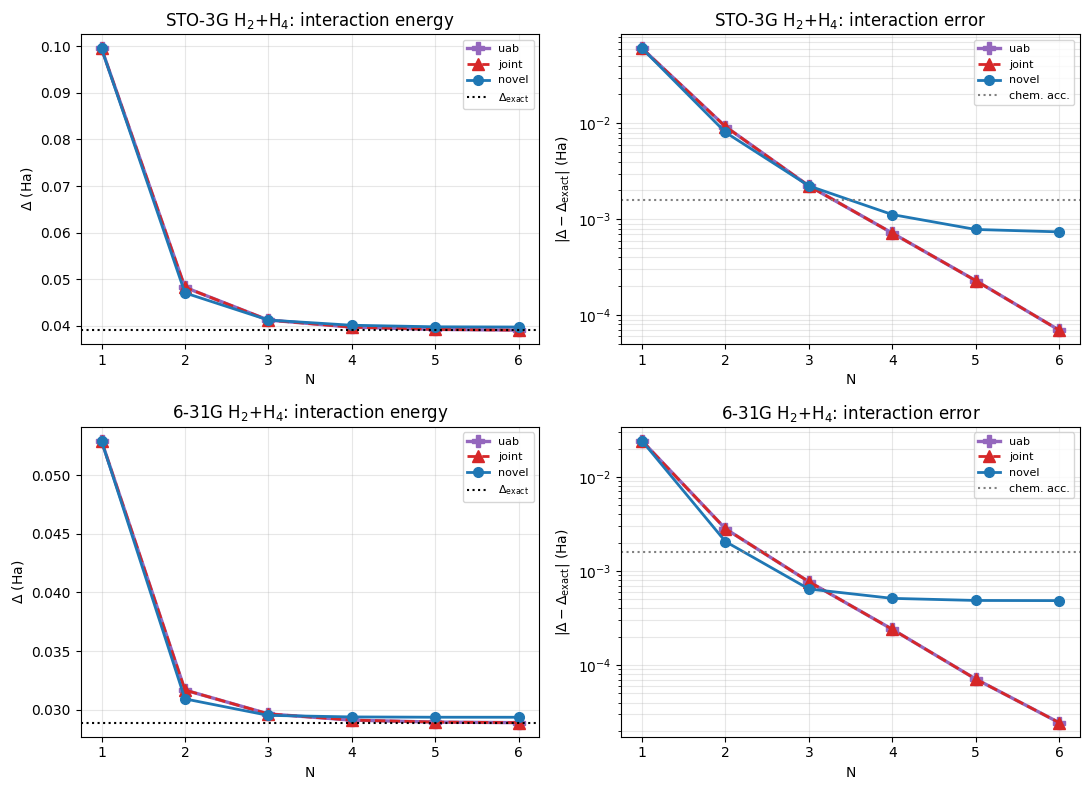

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/hetero/h2h4_uab_interaction_vs_N.png


In [11]:
# §9 plots
fig, axes = plt.subplots(len(BASIS_LIST), 2, figsize=(11, 4.0 * len(BASIS_LIST)))
if len(BASIS_LIST) == 1:
    axes = np.array([axes])
for row, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    sub = df_h2h4[df_h2h4['basis'] == basis]
    ax = axes[row, 0]
    for name in H2H4_VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['delta'], color=st['color'], marker=st['marker'],
                ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(delta_exact_h2h4[basis], color='k', ls=':', label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} H$_2$+H$_4$: interaction energy')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for name in H2H4_VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.semilogy(s['N'], np.maximum(s['err_int'], 1e-16),
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='chem. acc.')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ (Ha)')
    ax.set_title(rf'{label} H$_2$+H$_4$: interaction error')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
path = os.path.join(HETERO_DIR, 'h2h4_uab_interaction_vs_N.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


### 8b / 9b. Size consistency at $R = 1000$ Å (6-31G) — dressed-sum $U_{AB}$

$$
\Delta(N) = E_{\mathrm{uab}}(R=1000, N) - E_A^{\mathrm{QKD}}(N) - E_B^{\mathrm{QKD}}(N).
$$

Monomers: full H$_2$ ($\mathrm{H_2}\cdots\mathrm{H_2}$); H$_2$ CAS(2e,2o) + H$_4$ CAS(4e,4o) for $\mathrm{H_2}\cdots\mathrm{H_4}$. Also report vs $E_{\mathrm{exact}}(1000)$. Expect $|\Delta| \to 0$.


In [12]:
# §8b/9b — SC at R=1000 with QKD monomers
SC_BASIS = '6-31g'
SC_N_MAX = 6
SC_DIMS = list(range(1, SC_N_MAX + 1))
SC_VARIANTS = ['uab', 'joint', 'novel']


def sweep_mono_qkd(mono, dims, dt=None):
    us = bool(mono.get('use_sparse', False))
    H = mono['H_sp'] if us else mono['H']
    if dt is None:
        dt = compute_dt_sparse(H) if us else compute_dt(H)
    max_n = max(dims)
    if us:
        states = build_krylov_states_sparse(H, mono['ref'], max_n, dt)
        S_full, H_full = build_krylov_projected_sparse(H, states)
    else:
        states = build_krylov_states(H, mono['ref'], max_n, dt)
        S_full, H_full = build_krylov_matrices(H, states)
    rows = []
    for N in dims:
        gs_elec, eff = solve_gen_eig(H_full[:N, :N], S_full[:N, :N])
        E = gs_elec + mono['E_nuc']
        rows.append({'N': N, 'E_mono_qkd': E, 'eff_dim': eff,
                     'gs_err': abs(E - mono['gs_total'])})
    return pd.DataFrame(rows)


sc_rows = []
print('=' * 60)
print('Size consistency at R=1000 (6-31G) — U_AB')
print('=' * 60)

# H2+H2
print('H2...H2 ...')
mono_sc, systems_sc = build_all_systems(SC_BASIS, [R_NONINT])
sys_hh = systems_sc[R_NONINT]
E_ex_hh = sys_hh['gs_total']
df_h2_qkd = sweep_mono_qkd(mono_sc, SC_DIMS, dt=sys_hh['dt_tot'])
print(f'  ||Hab||={sys_hh["norm_H_ab"]:.3e}  E_exact={E_ex_hh:.10f}')

for N in SC_DIMS:
    print(f'  N={N} ...', end=' ', flush=True)
    E_sum = 2.0 * float(df_h2_qkd.loc[df_h2_qkd['N'] == N, 'E_mono_qkd'].iloc[0])
    for name in SC_VARIANTS:
        out = energy_from_state_list(sys_hh, VARIANT_BUILDERS[name](sys_hh, N))
        d_mono = out['gs_total'] - E_sum
        d_dim = out['gs_total'] - E_ex_hh
        sc_rows.append({
            'system': 'H2+H2', 'basis': SC_BASIS, 'R': R_NONINT, 'N': N,
            'variant': name, 'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
            'gs_total': out['gs_total'], 'E_exact': E_ex_hh,
            'E_mono_sum_qkd': E_sum, 'delta_vs_mono': d_mono,
            'delta_vs_dimer1000': d_dim, 'SC_err': abs(d_mono), 'gs_err': abs(d_dim),
        })
        print(f'{name}(D={d_mono:+.2e})', end='  ')
    print()
    gc.collect()
del systems_sc, mono_sc, sys_hh
gc.collect()

# H2+H4 CAS
print('H2...H4 (CAS) ...')
mono_h2 = build_h_chain_monomer(2, basis=SC_BASIS, cas=(2, 2))
mono_h4 = build_h_chain_monomer(4, basis=SC_BASIS, cas=(4, 4))
if SC_BASIS in h2h4_sys_non:
    sys_h4 = h2h4_sys_non[SC_BASIS]
else:
    sys_h4 = build_h2_h4_system(
        R_H2H4_NON, mono_h2, mono_h4, basis=SC_BASIS, use_cas66=True)
E_ex_h4 = sys_h4['gs_total']
df_a = sweep_mono_qkd(mono_h2, SC_DIMS, dt=sys_h4['dt_tot'])
df_b = sweep_mono_qkd(mono_h4, SC_DIMS, dt=sys_h4['dt_tot'])
print(f'  ||Hab||={sys_h4["norm_H_ab"]:.3e}  E_CAS={E_ex_h4:.10f}  '
      f'|CAS-sum|={abs(E_ex_h4 - mono_h2["gs_total"] - mono_h4["gs_total"]):.3e}')

for N in SC_DIMS:
    print(f'  N={N} ...', end=' ', flush=True)
    E_sum = (float(df_a.loc[df_a['N'] == N, 'E_mono_qkd'].iloc[0])
             + float(df_b.loc[df_b['N'] == N, 'E_mono_qkd'].iloc[0]))
    for name in SC_VARIANTS:
        out = energy_from_state_list(sys_h4, VARIANT_BUILDERS[name](sys_h4, N))
        d_mono = out['gs_total'] - E_sum
        d_dim = out['gs_total'] - E_ex_h4
        sc_rows.append({
            'system': 'H2+H4', 'basis': SC_BASIS, 'R': R_H2H4_NON, 'N': N,
            'variant': name, 'active': 'cas66',
            'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
            'gs_total': out['gs_total'], 'E_exact': E_ex_h4,
            'E_mono_sum_qkd': E_sum, 'delta_vs_mono': d_mono,
            'delta_vs_dimer1000': d_dim, 'SC_err': abs(d_mono), 'gs_err': abs(d_dim),
        })
        print(f'{name}(D={d_mono:+.2e})', end='  ')
    print()
    gc.collect()
del sys_h4, mono_h2, mono_h4
gc.collect()

df_sc = pd.DataFrame(sc_rows)
df_sc['abs_vs_mono'] = np.abs(df_sc['delta_vs_mono'])
df_sc['abs_vs_dimer1000'] = np.abs(df_sc['delta_vs_dimer1000'])
path_csv = os.path.join(HETERO_DIR, 'sc_R1000_uab_631g.csv')
df_sc.to_csv(path_csv, index=False)
print('Saved:', path_csv)
print(df_sc[df_sc['N'] == SC_N_MAX][['system', 'variant', 'abs_vs_mono', 'abs_vs_dimer1000']].to_string(
    index=False, float_format=lambda x: f'{x:.4e}'))


Size consistency at R=1000 (6-31G) — U_AB
H2...H2 ...
  ||Hab||=9.072e+00  E_exact=-2.3032286399
  N=1 ... uab(D=+1.69e-14)  joint(D=+1.69e-14)  novel(D=+1.69e-14)  
  N=2 ... uab(D=+3.97e-04)  joint(D=+3.97e-04)  novel(D=-6.86e-04)  
  N=3 ... uab(D=+6.45e-04)  joint(D=+6.45e-04)  novel(D=+1.39e-04)  
  N=4 ... uab(D=+3.28e-04)  joint(D=+3.28e-04)  novel(D=+6.68e-04)  
  N=5 ... uab(D=+3.45e-05)  joint(D=+3.45e-05)  novel(D=+5.85e-04)  
  N=6 ... uab(D=+3.53e-05)  joint(D=+3.53e-05)  novel(D=+5.18e-04)  
H2...H4 (CAS) ...
  ||Hab||=1.789e+00  E_CAS=-3.2890930921  |CAS-sum|=4.491e-09
  N=1 ... uab(D=-6.48e-14)  joint(D=-6.48e-14)  novel(D=-6.48e-14)  
  N=2 ... uab(D=+2.67e-04)  joint(D=+2.67e-04)  novel(D=-3.17e-04)  
  N=3 ... uab(D=+3.03e-05)  joint(D=+3.03e-05)  novel(D=-2.15e-04)  
  N=4 ... uab(D=+3.33e-05)  joint(D=+3.33e-05)  novel(D=-1.64e-05)  
  N=5 ... uab(D=+1.28e-05)  joint(D=+1.28e-05)  novel(D=+2.33e-05)  
  N=6 ... uab(D=+7.28e-06)  joint(D=+7.28e-06)  novel(D=+3.10e-0

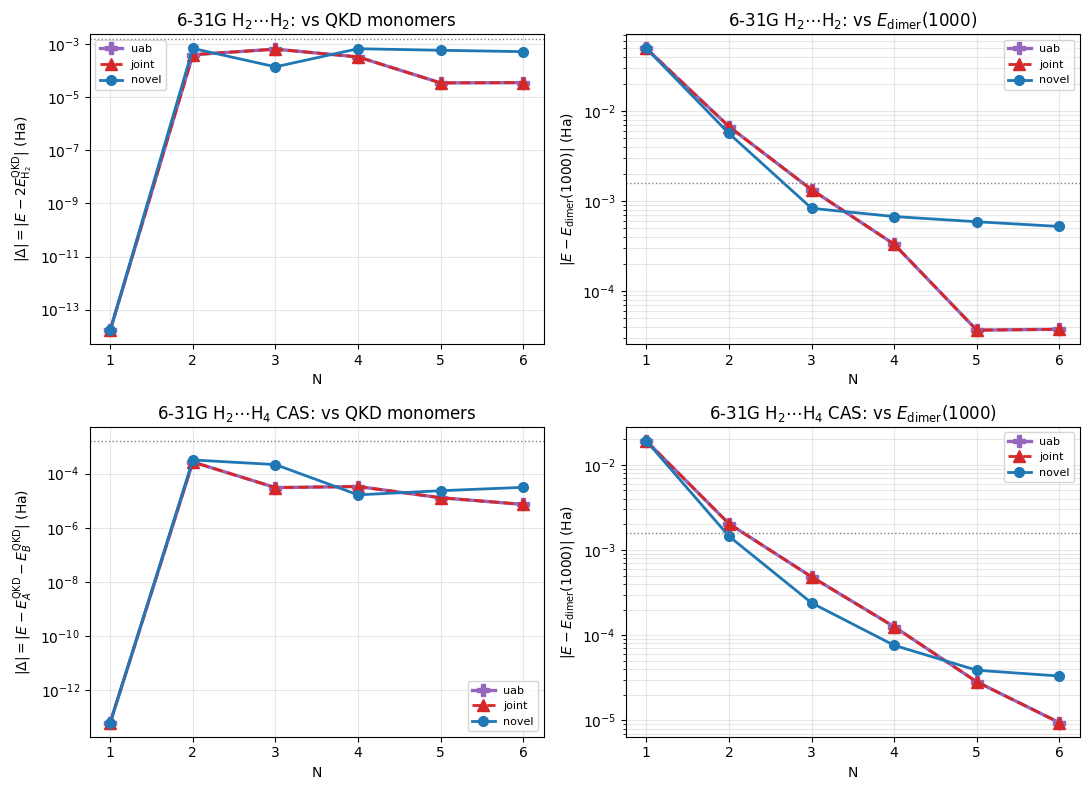

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/hetero/sc_R1000_uab_631g.png


In [13]:
# §8b/9b plots
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
panel = [
    ('H2+H2', r'H$_2\cdots$H$_2$', r'$|\Delta|=|E-2E_{\mathrm{H_2}}^{\mathrm{QKD}}|$'),
    ('H2+H4', r'H$_2\cdots$H$_4$ CAS', r'$|\Delta|=|E-E_A^{\mathrm{QKD}}-E_B^{\mathrm{QKD}}|$'),
]
for row, (system, sys_label, ylab) in enumerate(panel):
    sub_sys = df_sc[df_sc['system'] == system]
    for col, (key, title_ref) in enumerate([
        ('abs_vs_mono', 'QKD monomers'),
        ('abs_vs_dimer1000', r'$E_{\mathrm{dimer}}(1000)$'),
    ]):
        ax = axes[row, col]
        for name in SC_VARIANTS:
            s = sub_sys[sub_sys['variant'] == name]
            st = VARIANT_STYLE[name]
            ax.semilogy(s['N'], np.maximum(s[key], 1e-16),
                        color=st['color'], marker=st['marker'], ls=st['ls'],
                        lw=st['lw'], ms=st['ms'], label=name)
        ax.axhline(CHEM_ACC, color='gray', ls=':', lw=1)
        ax.set_xlabel('N')
        ax.set_ylabel((ylab if col == 0 else r'$|E-E_{\mathrm{dimer}}(1000)|$') + ' (Ha)')
        ax.set_title(rf'6-31G {sys_label}: vs {title_ref}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')
        ax.set_xticks(sorted(sub_sys['N'].unique()))
fig.tight_layout()
path = os.path.join(HETERO_DIR, 'sc_R1000_uab_631g.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


## 10. Convergence and singularity — $U_{AB}$ (+ Lanczos)

Compare the power Krylov under $U_{AB}$ with a **Lanczos-orthogonal** Krylov on $H_A+H_B$. Track

$$
|E - E_{\mathrm{exact}}|,\qquad
\lambda_{\min}(S),\qquad
\mathrm{cond}(\tilde H_{\mathrm{reg}}).
$$


In [14]:
# §10 — convergence + singularity for U_AB / Lanczos / novel
DIAG_DIR = os.path.join(FIG_ROOT, 'diagnostics')
os.makedirs(DIAG_DIR, exist_ok=True)

H_SING_ABS = 1e-12
H_SING_COND = 1e12
LANCZOS_BREAK = 1e-12
DIAG_VARIANTS = ['uab', 'lanczos', 'novel']
DIAG_N_MAX = {'H2+H2': dict(N_MAX_DEFAULT), 'H2+H4': dict(N_MAX_DEFAULT)}


def _apply_H(H, v):
    return np.asarray(H @ v, dtype=complex).reshape(-1)


def build_lanczos_on_Hsum(sys, N):
    """Lanczos Krylov on H_A+H_B (orthonormal)."""
    H = _H_sum_of(sys)
    V = []
    seed = np.asarray(sys['ref'], dtype=complex).reshape(-1).copy()
    nrm = np.linalg.norm(seed)
    v = seed / nrm
    V.append(v)
    beta = 0.0
    v_prev = None
    for _ in range(1, N):
        w = _apply_H(H, V[-1])
        alpha = np.vdot(V[-1], w).real
        w = w - alpha * V[-1]
        if v_prev is not None:
            w = w - beta * v_prev
        for b in V:
            w -= np.vdot(b, w) * b
        for b in V:
            w -= np.vdot(b, w) * b
        beta = float(np.linalg.norm(w))
        if beta <= LANCZOS_BREAK:
            break
        v_prev = V[-1]
        V.append(w / beta)
    return V


def conditioning_metrics(S, Ht, threshold=SVD_THRESH):
    S_h = 0.5 * (S + S.conj().T)
    Ht_h = 0.5 * (Ht + Ht.conj().T)
    s_vals = np.linalg.eigvalsh(S_h).real
    s_min, s_max = float(s_vals.min()), float(s_vals.max())
    cond_S = float(s_max / max(abs(s_min), 1e-300))
    h_vals = np.linalg.eigvalsh(Ht_h).real
    h_abs = np.abs(h_vals)
    h_min_abs, h_max_abs = float(h_abs.min()), float(h_abs.max())
    cond_H = float(h_max_abs / max(h_min_abs, 1e-300))
    s_full, s_vecs = la.eigh(S_h)
    s_vecs = s_vecs.T
    good = np.array([v for val, v in zip(s_full, s_vecs) if val > threshold])
    if len(good) == 0:
        h_reg_min_abs, cond_H_reg, n_kept = np.nan, np.nan, 0
    else:
        H_reg = 0.5 * ((good.conj() @ Ht_h @ good.T) + (good.conj() @ Ht_h @ good.T).conj().T)
        hr = np.abs(np.linalg.eigvalsh(H_reg).real)
        h_reg_min_abs, h_reg_max_abs = float(hr.min()), float(hr.max())
        cond_H_reg = float(h_reg_max_abs / max(h_reg_min_abs, 1e-300))
        n_kept = len(good)
    return {
        's_min': s_min, 's_max': s_max, 'cond_S': cond_S,
        'h_min_abs': h_min_abs, 'cond_H': cond_H,
        'h_reg_min_abs': h_reg_min_abs, 'cond_H_reg': cond_H_reg,
        'S_singular': bool(s_min <= threshold),
        'H_singular': bool(
            (not np.isnan(h_reg_min_abs) and h_reg_min_abs < H_SING_ABS)
            or (not np.isnan(cond_H_reg) and cond_H_reg > H_SING_COND)),
    }


DIAG_BUILDERS = {
    'uab': build_uab_states,
    'lanczos': build_lanczos_on_Hsum,
    'novel': VARIANT_BUILDERS['novel'],
}

diag_rows = []
for system in ['H2+H2', 'H2+H4']:
    for basis in BASIS_LIST:
        label = BASIS_CONFIG[basis]['label']
        N_max = DIAG_N_MAX[system][basis]
        dims = list(range(1, N_max + 1))
        print('=' * 60)
        print(f'§10  {system}  {label}')
        print('=' * 60)
        if system == 'H2+H2':
            mono, systems = build_all_systems(basis, [R_INT])
            sys = systems[R_INT]
            del systems, mono
        else:
            use_cas = (basis == '6-31g')
            ma = build_h_chain_monomer(2, basis=basis, cas=(2, 2) if use_cas else None)
            mb = build_h_chain_monomer(4, basis=basis, cas=(4, 4) if use_cas else None)
            if not use_cas:
                ma = build_h_chain_monomer(2, basis=basis)
                mb = build_h_chain_monomer(4, basis=basis)
            sys = build_h2_h4_system(R_H2H4_INT, ma, mb, basis=basis, use_cas66=use_cas)
        E_exact = sys['gs_total']
        print(f'  dim={sys["joint_dim"]}  ||Hab||={sys["norm_H_ab"]:.3e}')

        for N in dims:
            print(f'  N={N} ...', end=' ', flush=True)
            for name in DIAG_VARIANTS:
                states = DIAG_BUILDERS[name](sys, N)
                out = energy_from_state_list(sys, states)
                met = conditioning_metrics(out['S'], out['H'])
                gs_err = abs(out['gs_total'] - E_exact)
                diag_rows.append({
                    'system': system, 'basis': basis, 'label': label,
                    'N': N, 'variant': name,
                    'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                    'eff_frac': out['eff_dim'] / max(out['raw_dim'], 1),
                    'gs_err': gs_err, **met,
                })
                flag = ('S!' if met['S_singular'] else '') + ('H!' if met['H_singular'] else '')
                print(f'{name}(err={gs_err:.2e},smin={met["s_min"]:.1e}{flag})', end='  ')
            print()
            gc.collect()
        del sys
        gc.collect()
        print()

df_diag = pd.DataFrame(diag_rows)
path_csv = os.path.join(DIAG_DIR, 'uab_convergence_singularity.csv')
df_diag.to_csv(path_csv, index=False)
print('Saved:', path_csv)
sing = df_diag[df_diag['S_singular'] | df_diag['H_singular']]
print(f'Singular flags: {len(sing)} / {len(df_diag)}')


§10  H2+H2  STO-3G
  dim=64  ||Hab||=5.023e+00
  N=1 ... uab(err=4.66e-02,smin=1.0e+00)  lanczos(err=4.66e-02,smin=1.0e+00)  novel(err=4.66e-02,smin=1.0e+00)  
  N=2 ... uab(err=1.88e-02,smin=9.7e-03)  lanczos(err=1.73e-02,smin=1.0e+00)  novel(err=6.07e-03,smin=1.1e-04)  
  N=3 ... uab(err=6.59e-03,smin=2.6e-03)  lanczos(err=4.65e-03,smin=1.0e+00)  novel(err=8.74e-04,smin=8.5e-07)  
  N=4 ... uab(err=1.43e-03,smin=9.5e-04)  lanczos(err=8.15e-04,smin=1.0e+00)  novel(err=1.87e-04,smin=4.3e-10)  
  N=5 ... uab(err=5.47e-04,smin=2.1e-04)  lanczos(err=2.29e-04,smin=1.0e+00)  novel(err=9.21e-06,smin=3.3e-13S!H!)  
  N=6 ... uab(err=1.39e-04,smin=5.9e-05)  lanczos(err=4.19e-05,smin=1.0e+00)  novel(err=8.83e-07,smin=-2.8e-15S!H!)  

§10  H2+H2  6-31G
  dim=16384  ||Hab||=1.497e+01
  N=1 ... uab(err=5.99e-02,smin=1.0e+00)  lanczos(err=5.99e-02,smin=1.0e+00)  novel(err=5.99e-02,smin=1.0e+00)  
  N=2 ... uab(err=1.88e-02,smin=6.5e-04)  lanczos(err=1.87e-02,smin=1.0e+00)  novel(err=1.82e-02,smin=8

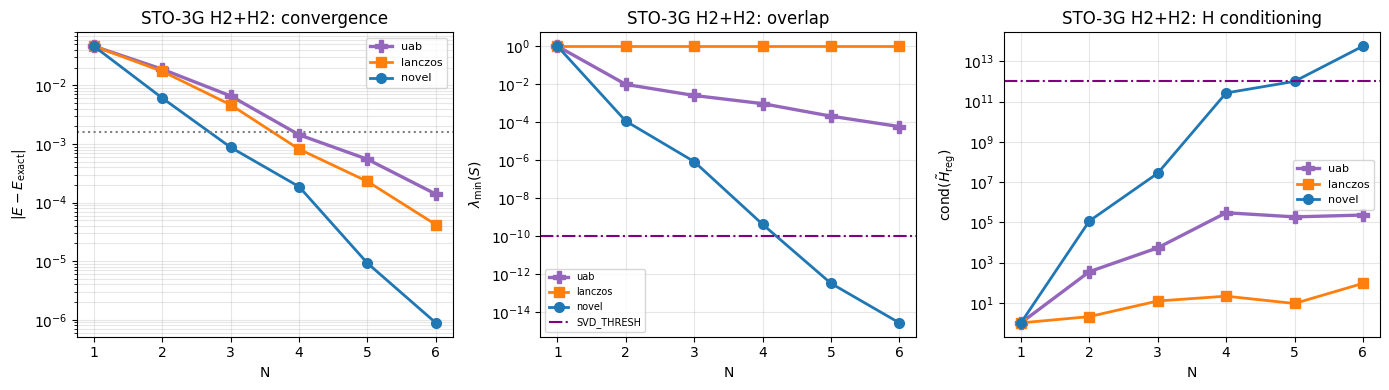

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/diagnostics/h2h2_sto3g_uab_diag.png


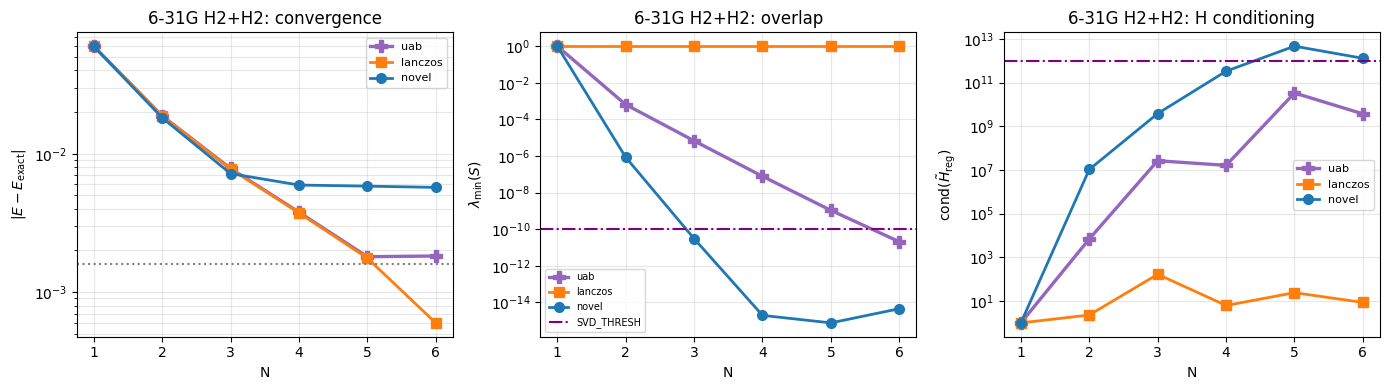

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/diagnostics/h2h2_631g_uab_diag.png


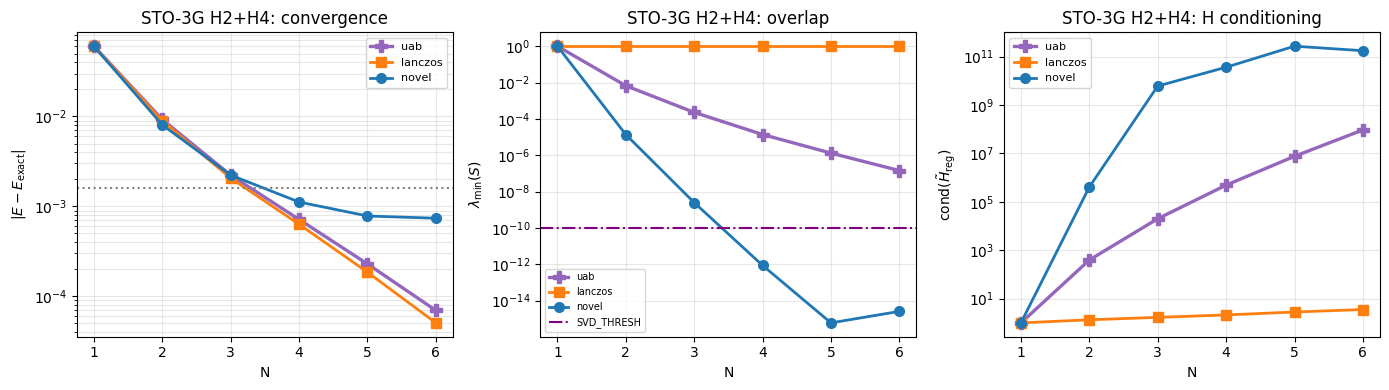

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/diagnostics/h2h4_sto3g_uab_diag.png


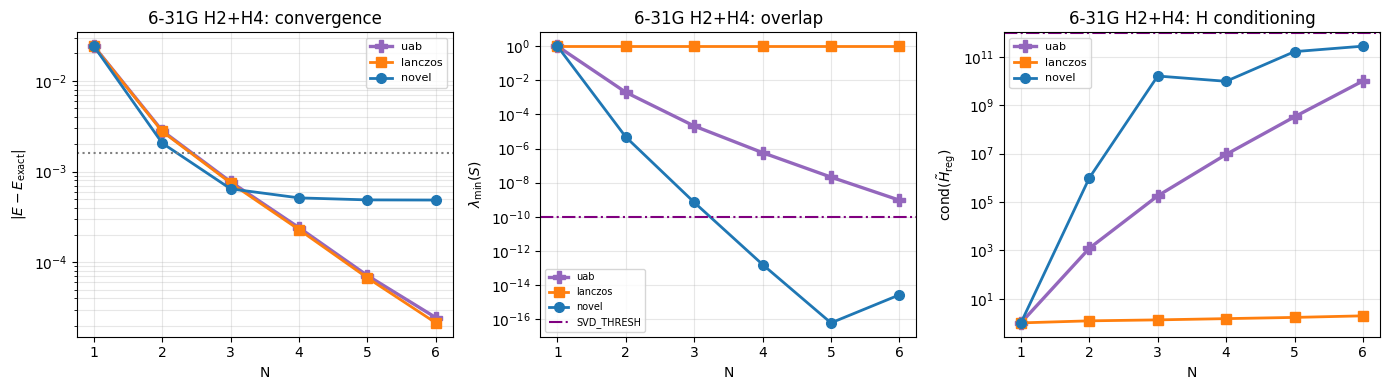

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_dressed_sum_uab/diagnostics/h2h4_631g_uab_diag.png

=== U_AB at N_max ===
H2+H2  sto-3g N=6: err=1.392e-04  s_min=5.905e-05  S_sing=False  H_sing=False
H2+H2  6-31g  N=6: err=1.824e-03  s_min=2.063e-11  S_sing=True  H_sing=False
H2+H4  sto-3g N=6: err=6.977e-05  s_min=1.426e-07  S_sing=False  H_sing=False
H2+H4  6-31g  N=6: err=2.451e-05  s_min=9.422e-10  S_sing=False  H_sing=False


In [15]:
# §10 plots
DIAG_STYLE = {
    'uab': VARIANT_STYLE['uab'],
    'lanczos': {'color': '#ff7f0e', 'marker': 's', 'ls': '-', 'lw': 2.0, 'ms': 7},
    'novel': VARIANT_STYLE['novel'],
}

for system in ['H2+H2', 'H2+H4']:
    for basis in BASIS_LIST:
        sub = df_diag[(df_diag['system'] == system) & (df_diag['basis'] == basis)]
        if len(sub) == 0:
            continue
        label = BASIS_CONFIG[basis]['label']
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        ax = axes[0]
        for name in DIAG_VARIANTS:
            s = sub[sub['variant'] == name]
            st = DIAG_STYLE[name]
            ax.semilogy(s['N'], np.maximum(s['gs_err'], 1e-16),
                        color=st['color'], marker=st['marker'], ls=st['ls'],
                        lw=st['lw'], ms=st['ms'], label=name)
        ax.axhline(CHEM_ACC, color='gray', ls=':')
        ax.set_xlabel('N'); ax.set_ylabel(r'$|E-E_{\mathrm{exact}}|$')
        ax.set_title(f'{label} {system}: convergence')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')

        ax = axes[1]
        for name in DIAG_VARIANTS:
            s = sub[sub['variant'] == name]
            st = DIAG_STYLE[name]
            ax.semilogy(s['N'], np.maximum(np.abs(s['s_min']), 1e-18),
                        color=st['color'], marker=st['marker'], ls=st['ls'],
                        lw=st['lw'], ms=st['ms'], label=name)
        ax.axhline(SVD_THRESH, color='purple', ls='-.', label='SVD_THRESH')
        ax.set_xlabel('N'); ax.set_ylabel(r'$\lambda_{\min}(S)$')
        ax.set_title(f'{label} {system}: overlap')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3, which='both')

        ax = axes[2]
        for name in DIAG_VARIANTS:
            s = sub[sub['variant'] == name]
            st = DIAG_STYLE[name]
            ax.semilogy(s['N'], np.maximum(s['cond_H_reg'], 1.0),
                        color=st['color'], marker=st['marker'], ls=st['ls'],
                        lw=st['lw'], ms=st['ms'], label=name)
        ax.axhline(H_SING_COND, color='purple', ls='-.')
        ax.set_xlabel('N'); ax.set_ylabel(r'$\mathrm{cond}(\tilde H_{\mathrm{reg}})$')
        ax.set_title(f'{label} {system}: H conditioning')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')
        fig.tight_layout()
        fname = f'{system.replace("+","").lower()}_{basis.replace("-","")}_uab_diag.png'
        outp = os.path.join(DIAG_DIR, fname)
        fig.savefig(outp, dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved:', outp)

print()
print('=== U_AB at N_max ===')
for system in ['H2+H2', 'H2+H4']:
    for basis in BASIS_LIST:
        sub = df_diag[(df_diag['system'] == system) & (df_diag['basis'] == basis)
                      & (df_diag['variant'] == 'uab')]
        if len(sub) == 0:
            continue
        row = sub.loc[sub['N'].idxmax()]
        print(f"{system:6s} {basis:6s} N={int(row['N'])}: err={row['gs_err']:.3e}  "
              f"s_min={row['s_min']:.3e}  S_sing={row['S_singular']}  H_sing={row['H_singular']}")
